In [5]:
import sys
import os
from google.colab import drive

# 1. Association de mon Google Drive au notebook Colab
drive.mount('/content/drive')

# 2. Définition du chemin exact vers mon dossier projet_4
dossier_projet = '/content/drive/MyDrive/Colab Notebooks/projet_4'

# 3. Se déplacer dans ce dossier pour que les fichiers de données (data) soient accessibles directement
os.chdir(dossier_projet)

# 4. Ajouter le dossier au système pour que "import utils" et des donnees fonctionne
sys.path.append(dossier_projet)

print("Dossier actuel :", os.getcwd())
print("Contenu du dossier :", os.listdir())

Mounted at /content/drive
✅ Dossier actuel : /content/drive/MyDrive/Colab Notebooks/projet_4
✅ Contenu du dossier : ['utils.py', 'data', 'Projet_4.ipynb']


In [6]:
# Installation des dépendances spécifiques au projet
%pip install -q transformers accelerate sentence-transformers pypdf

In [7]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import transformers
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from transformers import pipeline

from utils import print_chat

transformers.logging.set_verbosity_error()

In [8]:
# Partie 1 - La preuve par l'exemple : quand un LLM invente
# Étape 1 : charger le modèle de génération
generator = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")

print(type(generator).__name__, "-", generator.task)

assert generator.task == "text-generation", "La tâche du pipeline devrait être text-generation"
print("Exercice validé !")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

TextGenerationPipeline - text-generation
Exercice validé !


In [9]:
def ask_llm(prompt):
    """
    Send one message to the LLM and return its answer.

    Arguments:
    prompt -- the message to send, as a string

    Returns:
    answer -- the text generated by the model
    """
    conversation = generator([{"role": "user", "content": prompt}], max_new_tokens=80, do_sample=False)
    answer = conversation[0]["generated_text"][-1]["content"]
    return answer


print(ask_llm("Bonjour ! Qui es-tu, en une phrase ?"))

Je suis Qwen, un modèle de langage créé par Alibaba Cloud. Je suis disponible pour aider avec des questions ou des tâches spécifiques. Comment puis-je vous aider aujourd'hui ?


In [10]:
questions_test = [
    "A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?",
    "Est-ce qu'il y a un spa a l'Hotel Le Belvedere ?",
]

for question in questions_test:
    print_chat(question, ask_llm(question))

Client   : A quelle heure puis-je faire mon check-in a l'Hotel Le Belvedere ?
Assistant: Pour effectuer votre check-in à l'hôtel Le Belvedere, vous devrez suivre les instructions de la plateforme d'hébergement. Voici comment vous pouvez procéder :

1. Vérifiez le site web officiel ou le site Web du hotel pour obtenir les informations nécessaires.

2. Assurez-vous que vous avez bien rempli tous les
--------------------------------------------------------------------------------
Client   : Est-ce qu'il y a un spa a l'Hotel Le Belvedere ?
Assistant: Oui, il existe un spa à l'hôtel Le Belvedere. Le Belvedere est une propriété de luxe située dans le centre-ville de Paris, France. Il s'agit d'un hôtel de 5 étoiles qui offre des services de qualité pour les clients.

Le spa au Belvedere comprend plusieurs atouts :

1. Une piscine privée avec
--------------------------------------------------------------------------------


In [11]:
# Partie 2 - Les documents de Marc : tout mettre dans le prompt
pdf_paths = sorted(Path("data").glob("*.pdf"))

for path in pdf_paths:
    print(path.name)

assert len(pdf_paths) == 5, f"5 fichiers PDF attendus dans data/, {len(pdf_paths)} trouvés"
print("\nLes 5 documents de Marc sont bien là !")

activites_et_evenements.pdf
chambres_et_tarifs.pdf
familles_animaux_accessibilite.pdf
informations_pratiques.pdf
restaurant_et_bien_etre.pdf

Les 5 documents de Marc sont bien là !


In [12]:
reader = PdfReader("data/informations_pratiques.pdf")

print(f"informations_pratiques.pdf contient {len(reader.pages)} pages")

informations_pratiques.pdf contient 4 pages


In [13]:
# Étape 2 : extraire le texte d'une page
page_text = reader.pages[0].extract_text()

print(page_text)

assert isinstance(page_text, str) and len(page_text) > 100, "page_text devrait contenir le texte de la première page"
assert "réception" in page_text.lower(), "La première page devrait parler de la réception"
print("\nExercice validé !")

Horaires de la réception
La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h. En dehors de ces horaires, un
numéro d'astreinte est affiché à l'entrée pour toute urgence. Le check-in démarre à 15h et le check-out se fait
avant 11h. Un départ tardif jusqu'à 13h peut être accordé gratuitement selon la disponibilité des chambres, il
suffit de le demander la veille à la réception. Une arrivée tardive après 22h doit être annoncée à l'avance par
téléphone ou email pour que le personnel de nuit prépare la remise des clés.
Hôtel Le Belvédère - 12 avenue du Lac, 74000 Annecy - Documentation interne - page 1

Exercice validé !


In [14]:
rows = []
for path in pdf_paths:
    reader = PdfReader(path)
    for page in reader.pages:
        lines = page.extract_text().split("\n")
        rows.append({
            "source": path.name,             # le fichier PDF d'origine
            "title": lines[0],               # la première ligne de la page est le titre de la rubrique
            "text": "\n".join(lines[1:-1]),  # le texte, sans la ligne de titre ni le pied de page
        })

pages = pd.DataFrame(rows)
print(f"{len(pages)} rubriques extraites des {len(pdf_paths)} PDF")
display(pages)

assert len(pages) == 15, f"15 rubriques attendues, {len(pages)} trouvées"
print("Documentation chargée !")

15 rubriques extraites des 5 PDF


,source,title,text
0,activites_et_evenements.pdf,Activités et alentours,L'hôtel loue des vélos électriques à l'accueil...
1,activites_et_evenements.pdf,Séminaires et événements,"L'hôtel dispose de deux salles de séminaire, p..."
2,chambres_et_tarifs.pdf,Chambres et tarifs,L'hôtel propose 42 chambres réparties en quatr...
3,chambres_et_tarifs.pdf,Politique d'annulation et de paiement,L'annulation est gratuite jusqu'à 48h avant la...
4,chambres_et_tarifs.pdf,Climatisation et confort des chambres,Toutes les chambres de l'hôtel sont climatisée...
5,familles_animaux_accessibilite.pdf,Familles et enfants,Les lits bébé et les chaises hautes sont fourn...
6,familles_animaux_accessibilite.pdf,Animaux domestiques,Les animaux domestiques de moins de 10 kg sont...
7,familles_animaux_accessibilite.pdf,Accessibilité PMR,L'hôtel dispose de 4 chambres adaptées aux per...
8,informations_pratiques.pdf,Horaires de la réception,La réception de l'Hôtel Le Belvédère est ouver...
9,informations_pratiques.pdf,Wifi et connexion internet,Le wifi est gratuit et illimité dans toutes le...


Documentation chargée !


In [15]:
# Étape 3 : mettre la documentation en forme (Markdown)
pages["section"] = pages.apply(
    lambda row: f"## {row['title']}\n\n{row['text']}",
    axis=1
)
context_md = "\n".join(pages["section"])

print(context_md[:450])
print("[...]")
print(f"\nLongueur totale de la documentation : {len(context_md.split())} mots")

assert "section" in pages.columns, "Il manque la colonne section dans pages"
assert context_md.count("## ") == 15, "Le contexte devrait contenir les 15 titres de rubriques"
assert "## Spa et bien-être" in context_md, "Chaque rubrique devrait apparaître comme un titre markdown"
print("Exercice validé !")

## Activités et alentours

L'hôtel loue des vélos électriques à l'accueil pour 20 euros la demi-journée. Un ponton privé permet de
pratiquer le paddle et le kayak gratuitement pour les clients, de juin à septembre. Le sentier de randonnée du
Semnoz est accessible en 20 minutes de marche depuis l'hôtel. Le marché d'Annecy se tient le jeudi, le
vendredi et le dimanche matin dans la vieille ville, à environ 10 minutes à pied. Les canaux et la vieill
[...]

Longueur totale de la documentation : 1415 mots
Exercice validé !


In [16]:
# Étape 4 : construire le prompt
ROLE = (
    "Tu es l'assistant virtuel de l'Hôtel Le Belvédère, au bord du lac d'Annecy.\n"
    "Voici la documentation officielle de l'hôtel :"
)

CONSIGNE = (
    "Réponds en une ou deux phrases, uniquement à partir des informations "
    "de la documentation ci-dessus. Si l'information ne s'y trouve pas, réponds exactement : "
    '"Je ne sais pas, je vous invite à contacter la réception."'
)


def build_prompt(context, question):
    """
    Build the prompt sent to the LLM from a context and a question.

    Arguments:
    context -- the documentation the answer must be based on, as a string
    question -- the client's question, as a string

    Returns:
    prompt -- the full prompt, as a string
    """

    prompt = f"{ROLE}\n\n{context}\n\nQuestion d'un client : {question}\n{CONSIGNE}"

    return prompt


test_prompt = build_prompt("## Piscine\n\nLa piscine est ouverte de 8h à 20h.", "La piscine est-elle chauffée ?")
print(test_prompt)

prompt_attendu = (
    f"{ROLE}\n\n## Piscine\n\nLa piscine est ouverte de 8h à 20h.\n\n"
    f"Question d'un client : La piscine est-elle chauffée ?\n{CONSIGNE}"
)
assert test_prompt == prompt_attendu, \
    "Le prompt doit suivre exactement le modèle (ROLE, ligne vide, contexte, ligne vide, question, consigne) : " \
    "c'est la garantie que tes résultats seront identiques à ceux du notebook"
print("\nExercice validé !")

Tu es l'assistant virtuel de l'Hôtel Le Belvédère, au bord du lac d'Annecy.
Voici la documentation officielle de l'hôtel :

## Piscine

La piscine est ouverte de 8h à 20h.

Question d'un client : La piscine est-elle chauffée ?
Réponds en une ou deux phrases, uniquement à partir des informations de la documentation ci-dessus. Si l'information ne s'y trouve pas, réponds exactement : "Je ne sais pas, je vous invite à contacter la réception."

Exercice validé !


In [18]:
questions_hotel = [
    "A quelle heure commence le check-in ?",
    "Le wifi est-il gratuit ?",
    "Combien coute une chambre Classique en basse saison ?",
    "Est-ce que vous acceptez les paiements en Bitcoin ?",
]

start = time.time()
for question in questions_hotel:
    ### START CODE HERE ###

    # construire le prompt
    prompt = build_prompt("\n\n".join(pages["section"]), question)
    # afficher la réponse du llm a l'écran
    response = ask_llm(prompt)

    print(response)

    ### END CODE HERE ###

print(f"Temps total : {time.time() - start:.0f} secondes pour {len(questions_hotel)} questions")

La réception de l'Hôtel Le Belvédère est ouverte tous les jours de 7h à 22h.
Je ne sais pas, je vous invite à contacter la réception.
Une chambre Classique en basse saison coûte 120 euros par nuit.
Je ne sais pas, je vous invite à contacter la réception.
Temps total : 1125 secondes pour 4 questions


In [19]:
# Partie 3 - Le RAG : ne donner au modèle que les bonnes pages
# Étape 5 : charger le modèle d'embedding
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedder = SentenceTransformer(EMBEDDING_MODEL)

dimension = embedder.encode(["Bonjour Marc !"]).shape[1]
print(f"Modèle d'embedding chargé : chaque texte devient un vecteur de {dimension} nombres")

assert dimension == 384, "Le modèle devrait produire des vecteurs de dimension 384"
print("Exercice validé !")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modèle d'embedding chargé : chaque texte devient un vecteur de 384 nombres
Exercice validé !


In [20]:
phrases = [
    "La piscine est chauffée à 27 degrés.",
    "Quelle est la température de l'eau de la piscine ?",
    "Le petit-déjeuner est servi jusqu'à 10h30.",
]

vecteurs = embedder.encode(phrases, normalize_embeddings=True)
print("Forme de la matrice de vecteurs :", vecteurs.shape)

print(f"\nSimilarité (piscine / température de l'eau) : {vecteurs[0] @ vecteurs[1]:.3f}")
print(f"Similarité (piscine / petit-déjeuner)        : {vecteurs[0] @ vecteurs[2]:.3f}")

Forme de la matrice de vecteurs : (3, 384)

Similarité (piscine / température de l'eau) : 0.729
Similarité (piscine / petit-déjeuner)        : 0.026


In [22]:
# Étape 6 : transformer les 15 rubriques en vecteurs
chunk_embeddings = embedder.encode(
    pages["section"].tolist(),
    normalize_embeddings=True
)

print(f"Notre base de données vectorielle : {chunk_embeddings.shape[0]} vecteurs de dimension {chunk_embeddings.shape[1]}")

assert chunk_embeddings.shape == (15, 384), f"Forme attendue (15, 384), obtenue {chunk_embeddings.shape}"
print("Exercice validé !")

Notre base de données vectorielle : 15 vecteurs de dimension 384
Exercice validé !


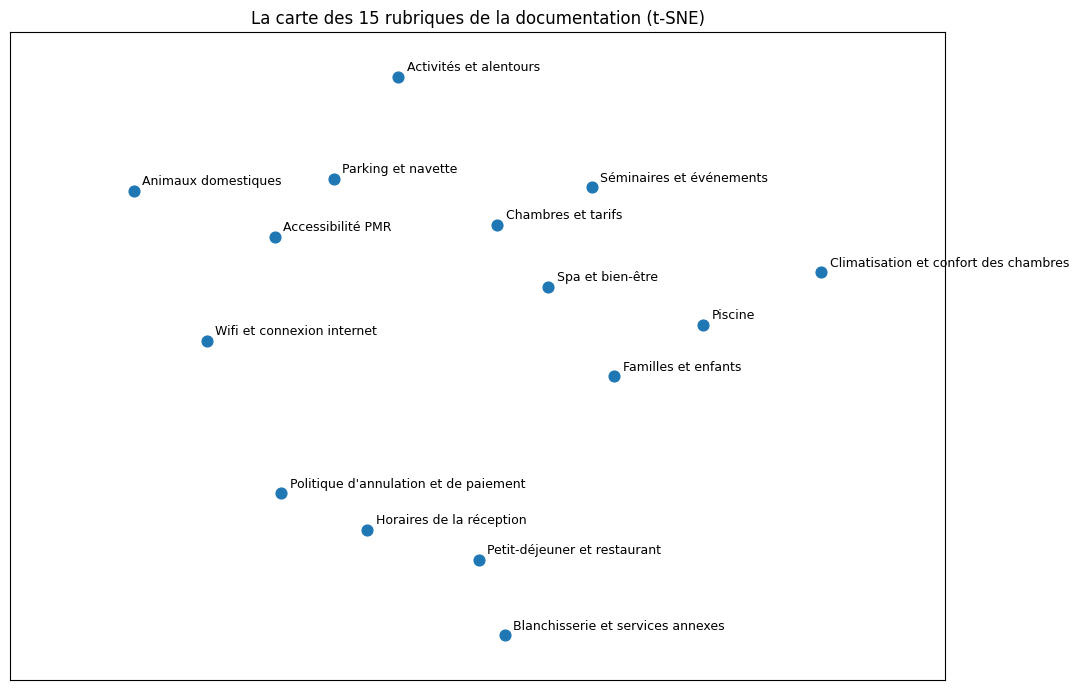

Exercice validé !


In [23]:
# Étape 7 (bonus) : dessiner la carte des embeddings
tsne = TSNE(perplexity=5, random_state=42)
coords = tsne.fit_transform(chunk_embeddings)

plt.figure(figsize=(11, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=60)
for i, row in pages.iterrows():
    plt.annotate(row["title"], (coords[i, 0], coords[i, 1]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
plt.title("La carte des 15 rubriques de la documentation (t-SNE)")
plt.xticks([])
plt.yticks([])
plt.margins(x=0.18, y=0.08)
plt.tight_layout()
plt.show()

assert coords.shape == (15, 2), f"Forme attendue (15, 2), obtenue {coords.shape}"
print("Exercice validé !")

In [24]:
# Étape 8 : la recherche
def search(question, top_k=2):
    """
    Retrieve the top_k pages most relevant to a question.

    Arguments:
    question -- the client's question, as a string
    top_k -- number of pages to return

    Returns:
    results -- the top_k rows of pages, with an added score column,
               sorted from most to least relevant
    """

    question_embedding = embedder.encode([question],normalize_embeddings=True)[0]
    similarities = chunk_embeddings @ question_embedding
    top_indices = np.argsort(-similarities)[:top_k]

    results = pages.iloc[top_indices].copy()
    results["score"] = similarities[top_indices]
    return results


test_results = search("Est-ce qu'il y a une piscine ?")
display(test_results[["source", "title", "score"]])

assert len(test_results) == 2, "top_k=2 devrait retourner 2 résultats"
assert test_results.iloc[0]["title"] == "Piscine", \
    "La rubrique la plus pertinente pour cette question devrait être « Piscine »"
print("Exercice validé !")

,source,title,score
13,restaurant_et_bien_etre.pdf,Piscine,0.570319
5,familles_animaux_accessibilite.pdf,Familles et enfants,0.329833


Exercice validé !


In [25]:
# Étape 9 : l'assistant complet
def answer_question(question, top_k=2):
    """
    Answer a question using the full RAG pipeline.

    Arguments:
    question -- the client's question, as a string
    top_k -- number of pages to retrieve

    Returns:
    answer -- the generated answer, as a string
    retrieved -- the DataFrame of pages used as context
    """

    retrieved = search(question)
    context = "\n\n".join(retrieved)
    prompt = build_prompt(context, question)
    answer = ask_llm(prompt)

    return answer, retrieved


answer, sources = answer_question("A quelle heure ouvre la réception ?")
print_chat("A quelle heure ouvre la réception ?", answer, sources)

assert sources.iloc[0]["title"] == "Horaires de la réception", \
    "La question sur la réception devrait retrouver la rubrique des horaires"
print("Exercice validé !")

Client   : A quelle heure ouvre la réception ?
Sources  : Horaires de la réception (0.75), Petit-déjeuner et restaurant (0.59)
Assistant: 15:00
--------------------------------------------------------------------------------
Exercice validé !


In [26]:
start = time.time()
for question in questions_hotel:
    answer, sources = answer_question(question)
    print_chat(question, answer, sources)
print(f"Temps total : {time.time() - start:.0f} secondes pour {len(questions_hotel)} questions")

Client   : A quelle heure commence le check-in ?
Sources  : Horaires de la réception (0.59), Politique d'annulation et de paiement (0.53)
Assistant: 15:00
--------------------------------------------------------------------------------
Client   : Le wifi est-il gratuit ?
Sources  : Wifi et connexion internet (0.65), Politique d'annulation et de paiement (0.26)
Assistant: Le wifi est gratuit dans le Hôtel Le Belvédère. Je vous invite à contacter la réception pour plus d'informations.
--------------------------------------------------------------------------------
Client   : Combien coute une chambre Classique en basse saison ?
Sources  : Chambres et tarifs (0.57), Climatisation et confort des chambres (0.45)
Assistant: 100 EUR
--------------------------------------------------------------------------------
Client   : Est-ce que vous acceptez les paiements en Bitcoin ?
Sources  : Politique d'annulation et de paiement (0.27), Wifi et connexion internet (0.18)
Assistant: Je ne sais pas, je